# Global $vs.$ local fidelity susceptibility

In [15]:
import numpy as np
import gzip
import pickle

from qs_mps.mps_class import MPS
from qs_mps.applications.ISING.utils import discrete_fidelity_susceptibility

from qphaset.phases import gstates_to_rdms_matrix_qs_mps
from qphaset.fidelity import uhlmann_fidelity

import matplotlib.pyplot as plt

### Loading the states

In [16]:
model_name = "Cluster"
l = 15
n = 10
h_i, h_f = 0.5, 0.6

model_name = "Cluster"
l = 50
n = 64
h_i, h_f = 0.5, 1.5

model_name = "Rydberg"
l = 20
n = 30
h_i, h_f = 1, 3
params = np.linspace(1, 3, n), np.linspace(1.8, 3, n) # upside-down

model_name = "ANNNI"
l = 12
n = 30
h_i, h_f = 0.5, 2.1
params = np.linspace(0.5, 2.1, n), np.linspace(1.6, 0.01, n) # upside-down

# params = np.linspace(h_i, h_f, n), np.linspace(h_f, h_i, n) # upside-down

couplings = np.linspace(h_i,h_f,n)
a = abs(couplings[0] - couplings[1])

params = map(lambda m: m.flatten(), np.meshgrid(*params, indexing='xy'))
params = tuple(params)
params = np.stack(params).T
params_extent = np.concatenate([np.min(params, axis=0), np.max(params, axis=0)])
params_extent = tuple(params_extent[[0, 2, 1, 3]])

device = 'pc'
# device = 'ngt'

if device == 'pc':
    device_path = "D:/code"
elif device == 'ngt':
    device_path = "/eos/user/f/fdimarca"

# dmrg params
d = 2
chi = 100 # bond dimension
c1 = 1e-3 # eps symm. break.

if model_name == 'ANNNI':
    path_to_tensor = f"{device_path}/projects/2_ANNNI/results/data"
    path_to_figures = f"{device_path}/projects/2_ANNNI/figures"
    axis_name = ('k', 'h')

elif model_name == 'Cluster':
    path_to_tensor = f"{device_path}/projects/3_CLUSTER/results/data"
    path_to_figures = f"{device_path}/projects/3_CLUSTER/figures"
    axis_name = ('k', 'h')

elif model_name == 'Rydberg':
    path_to_tensor = f"{device_path}/projects/4_RYDBERG/results/data"
    path_to_figures = f"{device_path}/projects/4_RYDBERG/figures"
    axis_name = ('$\\Delta/\\Omega$', '$R_b/a$')

else:
    raise SyntaxError("Choose a valid model among 'ANNNI', 'Cluster', and 'Rydberg'")


filename = f'{path_to_tensor}/{model_name}_L_{l}_lambda_1_{params_extent[2]}-{params_extent[3]}_lambda_2_{params_extent[0]}-{params_extent[1]}_npoints_{n}x{n}_chi_{chi}_eps_{c1}.pkl'
# filename = f'{path_to_tensor}/{model_name}_L_{l}_lambda_1_{params_extent[2]}-{params_extent[3]}_lambda_2_{params_extent[0]}-{params_extent[1]}_npoints_{n}x{n}.pkl'

with gzip.open(filename, 'rb') as f:
    data = pickle.load(f)
params = data['params']
l, n = data['l'], data['n']
gstates = data['gstates']
stats = data['stats']


## Find reduced fidelity susceptibility (no vector field)

In [17]:
def sanitize_state(state):
    # ensure flat list of arrays
    return [np.array(t) for t in state]

gstates = [
    sanitize_state(state)
    for row in gstates
    for state in (row if isinstance(row, (list, np.ndarray)) else [row])
]

import types
if isinstance(gstates[0], (types.BuiltinFunctionType, types.BuiltinMethodType)):
    gstates = [gstate() for gstate in gstates]

In [18]:
# Select sites for the partial trace (gstates -> rdms, ie ground states to reduced density matrices).
# Note the concept of site depends on the model. For example in the case of models based on the
# class SpinChainNNN, the site corresponds to 2 qubits.

sites = [(l // 2) - 2, (l // 2) - 1, l // 2, (l // 2) + 1, (l // 2) + 2]
sites = [(l // 2) - 1, l // 2, (l // 2) + 1]
# sites = [l // 2, (l // 2) + 1]
# sites = [l // 2]

rdms = gstates_to_rdms_matrix_qs_mps(gstates, sites=sites, generalized=True)

rdm comp: 900: 100%|██████████| 900/900 [00:20<00:00, 43.07it/s]


In [19]:
rdms.shape

(30, 30, 8, 8)

k-rdms: 3, couplings: [0.5 1.6]
k-rdms: 3, couplings: [0.55517241 1.6       ]
k-rdms: 3, couplings: [0.61034483 1.6       ]
k-rdms: 3, couplings: [0.66551724 1.6       ]
k-rdms: 3, couplings: [0.72068966 1.6       ]
k-rdms: 3, couplings: [0.77586207 1.6       ]
k-rdms: 3, couplings: [0.83103448 1.6       ]
k-rdms: 3, couplings: [0.8862069 1.6      ]
k-rdms: 3, couplings: [0.94137931 1.6       ]
k-rdms: 3, couplings: [0.99655172 1.6       ]
k-rdms: 3, couplings: [1.05172414 1.6       ]
k-rdms: 3, couplings: [1.10689655 1.6       ]
k-rdms: 3, couplings: [1.16206897 1.6       ]
k-rdms: 3, couplings: [1.21724138 1.6       ]
k-rdms: 3, couplings: [1.27241379 1.6       ]
k-rdms: 3, couplings: [1.32758621 1.6       ]
k-rdms: 3, couplings: [1.38275862 1.6       ]
k-rdms: 3, couplings: [1.43793103 1.6       ]
k-rdms: 3, couplings: [1.49310345 1.6       ]
k-rdms: 3, couplings: [1.54827586 1.6       ]
k-rdms: 3, couplings: [1.60344828 1.6       ]
k-rdms: 3, couplings: [1.65862069 1.6       ]
k-rd

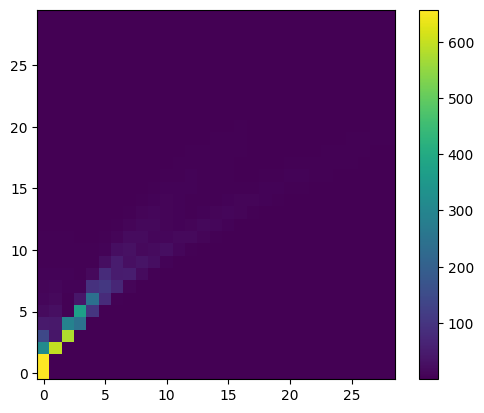

In [20]:
fidelity_rdms = []
for i in range(n):
    fidelity_row_rdms = []
    for j in range(n-1):
        print(f"k-rdms: {len(sites)}, couplings: {params[i+j]}")
        fidelity_row_rdms.append(uhlmann_fidelity(rdms[i,j],rdms[i,j+1]))
    fidelity_rdms.append(fidelity_row_rdms)

dfss_rdms = []
for fid_row in fidelity_rdms:
    dfs = discrete_fidelity_susceptibility(fid=fid_row, a=a)
    dfss_rdms.append(dfs)
plt.imshow(np.asarray(dfss_rdms), origin='lower')
plt.colorbar();
# plt.savefig(f"{path_to_figures}/{model_name}_L_{l}_{n}x{n}_total_state_no_convol.png")

## Find global fidelity susceptibility

L: 12, couplings: [0.5 1.6]
L: 12, couplings: [0.55517241 1.6       ]
L: 12, couplings: [0.61034483 1.6       ]
L: 12, couplings: [0.66551724 1.6       ]
L: 12, couplings: [0.72068966 1.6       ]
L: 12, couplings: [0.77586207 1.6       ]
L: 12, couplings: [0.83103448 1.6       ]
L: 12, couplings: [0.8862069 1.6      ]
L: 12, couplings: [0.94137931 1.6       ]
L: 12, couplings: [0.99655172 1.6       ]
L: 12, couplings: [1.05172414 1.6       ]
L: 12, couplings: [1.10689655 1.6       ]
L: 12, couplings: [1.16206897 1.6       ]
L: 12, couplings: [1.21724138 1.6       ]
L: 12, couplings: [1.27241379 1.6       ]
L: 12, couplings: [1.32758621 1.6       ]
L: 12, couplings: [1.38275862 1.6       ]
L: 12, couplings: [1.43793103 1.6       ]
L: 12, couplings: [1.49310345 1.6       ]
L: 12, couplings: [1.54827586 1.6       ]
L: 12, couplings: [1.60344828 1.6       ]
L: 12, couplings: [1.65862069 1.6       ]
L: 12, couplings: [1.7137931 1.6      ]
L: 12, couplings: [1.76896552 1.6       ]
L: 12, cou

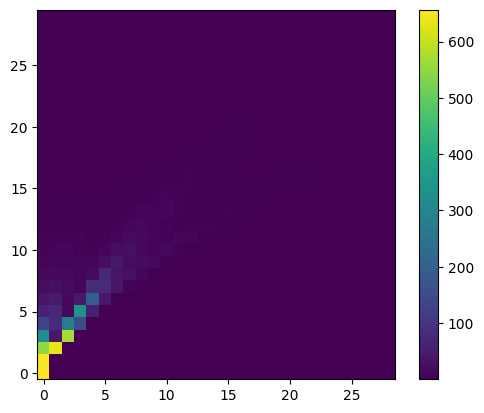

In [21]:
fidelity = []
for i in range(n):
    fidelity_row = []
    for j in range(n-1):
        print(f"L: {l}, couplings: {params[i+j]}")
        heis_chain_g = MPS(L=l, d=d, model=model_name, chi=chi, h=None, eps=c1, J=None, bc='obc')
        
        heis_chain_g.sites = gstates[i+j+i*(n-1)]
        heis_chain_g.ancilla_sites = gstates[i+j+i*(n-1)+1]

        fidelity_row.append(heis_chain_g._compute_norm(site=1, mixed=True).copy())
    fidelity.append(fidelity_row)

dfss = []
for fid_row in fidelity:
    dfs = discrete_fidelity_susceptibility(fid=fid_row, a=a)
    dfss.append(dfs)
plt.imshow(np.asarray(dfss), origin='lower')
plt.colorbar();
# plt.savefig(f"{path_to_figures}/{model_name}_L_{l}_{n}x{n}_total_state_no_convol.png")

## Comparison plot

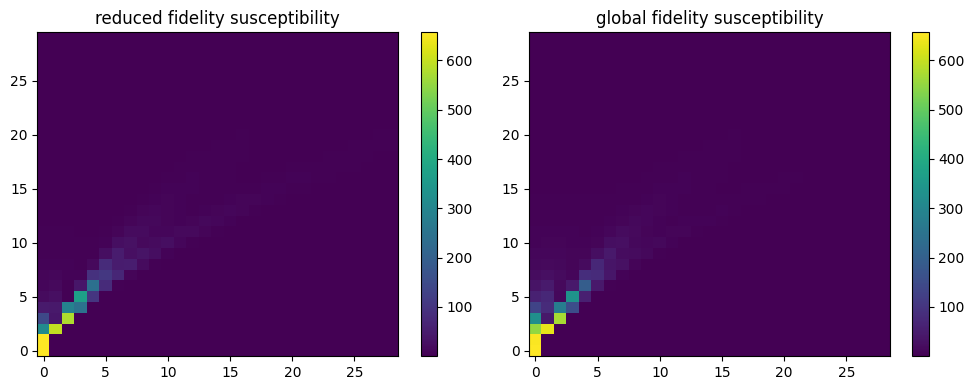

In [25]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

im0 = ax[0].imshow(np.asarray(dfss_rdms), origin='lower', aspect='auto')
ax[0].set_title("reduced fidelity susceptibility")
fig.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(np.asarray(dfss), origin='lower', aspect='auto')
ax[1].set_title("global fidelity susceptibility")
fig.colorbar(im1, ax=ax[1])
plt.tight_layout()
fig.savefig(f"{path_to_figures}/{model_name}_L_{l}_{n}x{n}_comparison_no_convol.png")